<a href="https://colab.research.google.com/github/shyamgadhiya/Predictive-Al-Operational-Forecasting/blob/main/ai_operation_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Problem Statement
## A district hospital wants to forecast day-to-day operational load - lab tests, ED arrivals,OPD visits, bed occupancy, ambulance calls - so the admin team can plan staffing, open surge beds early, and reduce patient wait times.You will build a small forecasting pipeline that takes a daily facility-level CSV and producesa next 7-day forecast per metric, with a simple capacity-breach alert.

In [1]:
import numpy as np
import pandas as pd

##**Data Loading**

In [3]:
import io
import pandas as pd

raw_data = """date,facility_id,facility_type,lab_tests,ed_arrivals,opd_visits,admissions,discharges,beds_occupied,beds_total,ambulance_calls,is_holiday
2026-08-01,GMC-AHM-001,District Hospital,1820,312,1540,78,65,410,500,41,False
2026-08-02,GMC-AHM-001,District Hospital,1905,298,1612,82,71,417,500,39,False
2026-08-03,GMC-AHM-001,District Hospital, 1640,260,980,55,52,388,500,28, True
2026-08-04,GMC-AHM-001,District Hospital,1780,290,1410,70,68,392,500,35, False
2026-08-05,GMC-AHM-001,District Hospital,1950,320,1680,85,75,420,500,44, False
2026-08-06,GMC-AHM-001,District Hospital,2010,355,1750,92,80,432,500,48, False
2026-08-07,GMC-AHM-001,District Hospital,1880,330,1600,80,72,425,500,42, False
2026-08-08,GMC-AHM-001,District Hospital,1750,300,1500,76,70,418,500,40, False
2026-08-09,GMC-AHM-001,District Hospital,1820,310,1555,79,73,420,500,41, False
2026-08-10,GMC-AHM-001,District Hospital,1610,255,950,52,50,386,500,30, True
2026-08-11,GMC-AHM-001,District Hospital,1790,295,1430,72,68,395,500,37, False
2026-08–12,GMC-AHM-001,District Hospital,1960,325,1670,86,77,422,500,45, False
2026-08-13,GMC-AHM-001,District Hospital, 2030,360,1770,93,82,434,500,50, False
2026–08–14,GMC-AHM-001,District Hospital,1890,335,1620,82,74,427,500,43, False
2026-08-15,GMC-AHM-001,District Hospital,1780,308,1520,77,72,419,500,41, False
2026–08–16,GMC-AHM-001,District Hospital,1840,318,1570,80,75,421,500,42, False
2026-08-17,GMC-AHM-001,District Hospital, 1640,262,975,55,53,388,500,29, True
2026–08–18,GMC-AHM-001,District Hospital, 1810,302,1450,73,69,397,500,38, False
2026-08-19,GMC-AHM-001,District Hospital, 1980,328,1690,87,78,425,500,46, False
2026-08-20,GMC-AHM-001,District Hospital,2055,365,1790,95,83,438,500,52, False
2026–08-21,GMC-AHM-001,District Hospital,1910,340,1640,84,76,430,500,44, False
2026-08-22,GMC-AHM-001,District Hospital,1800,312,1530,78,74,420,500,41, False
2026–08–23,GMC-AHM-001,District Hospital,1850,320,1580,81,76,422,500,42, False
2026-08-24,GMC-AHM-001,District Hospital,1660,270,990,56,54,390,500,30,True
2026–08-25,GMC-AHM-001,District Hospital,1830,305,1460,74,70,400,500,38, False
2026–08–26,GMC-AHM-001,District Hospital,2000,332,1710,88,80,427,500,47,False
2026-08-27,GMC-AHM-001,District Hospital,2080,372,1820,96,85,442,500,53, False
2026-08-28,GMC-AHM-001,District Hospital,1930,345,1660,85,77,432,500,45, False"""

# Clean Unicode hyphens/dashes from dates
clean_data = (
    raw_data.replace("–", "-").replace("—", "-").replace("−", "-")
)

# Load into DataFrame
df = pd.read_csv(io.StringIO(clean_data), skipinitialspace=True)
df.head()

,date,facility_id,facility_type,lab_tests,ed_arrivals,opd_visits,admissions,discharges,beds_occupied,beds_total,ambulance_calls,is_holiday
0,2026-08-01,GMC-AHM-001,District Hospital,1820,312,1540,78,65,410,500,41,False
1,2026-08-02,GMC-AHM-001,District Hospital,1905,298,1612,82,71,417,500,39,False
2,2026-08-03,GMC-AHM-001,District Hospital,1640,260,980,55,52,388,500,28,True
3,2026-08-04,GMC-AHM-001,District Hospital,1780,290,1410,70,68,392,500,35,False
4,2026-08-05,GMC-AHM-001,District Hospital,1950,320,1680,85,75,420,500,44,False


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   date             28 non-null     object
 1   facility_id      28 non-null     object
 2   facility_type    28 non-null     object
 3   lab_tests        28 non-null     int64 
 4   ed_arrivals      28 non-null     int64 
 5   opd_visits       28 non-null     int64 
 6   admissions       28 non-null     int64 
 7   discharges       28 non-null     int64 
 8   beds_occupied    28 non-null     int64 
 9   beds_total       28 non-null     int64 
 10  ambulance_calls  28 non-null     int64 
 11  is_holiday       28 non-null     bool  
dtypes: bool(1), int64(8), object(3)
memory usage: 2.6+ KB


##**Data Preprocessing For Required Schema**

In [5]:
# Convert date to datetime
df["date"] = pd.to_datetime(df["date"])

# Convert boolean column
df["is_holiday"] = df["is_holiday"].astype(str).str.strip().map({"True": True, "False": False})

# Explicitly cast numeric features
numeric_cols = [
    "lab_tests", "ed_arrivals", "opd_visits",
    "admissions", "discharges", "beds_occupied",
    "beds_total", "ambulance_calls"
]
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric)

# Add Day of Week and Weekend indicators
df["day_name"] = df["date"].dt.day_name()
df["day_of_week"] = df["date"].dt.dayofweek  # 0=Monday, 6=Sunday
df["is_weekend"] = df["day_of_week"].isin([5, 6])

# Verify datatypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   date             28 non-null     datetime64[ns]
 1   facility_id      28 non-null     object        
 2   facility_type    28 non-null     object        
 3   lab_tests        28 non-null     int64         
 4   ed_arrivals      28 non-null     int64         
 5   opd_visits       28 non-null     int64         
 6   admissions       28 non-null     int64         
 7   discharges       28 non-null     int64         
 8   beds_occupied    28 non-null     int64         
 9   beds_total       28 non-null     int64         
 10  ambulance_calls  28 non-null     int64         
 11  is_holiday       28 non-null     bool          
 12  day_name         28 non-null     object        
 13  day_of_week      28 non-null     int32         
 14  is_weekend       28 non-null     bool       

In [6]:
print("--- Missing Values Check ---")
print(df.isnull().sum())

print("\n--- Summary Statistics (describe) ---")
display(df.describe())

--- Missing Values Check ---
date               0
facility_id        0
facility_type      0
lab_tests          0
ed_arrivals        0
opd_visits         0
admissions         0
discharges         0
beds_occupied      0
beds_total         0
ambulance_calls    0
is_holiday         0
day_name           0
day_of_week        0
is_weekend         0
dtype: int64

--- Summary Statistics (describe) ---


,date,lab_tests,ed_arrivals,opd_visits,admissions,discharges,beds_occupied,beds_total,ambulance_calls,day_of_week
count,28,28.000000,28.000000,28.000000,28.00000,28.000000,28.000000,28.0,28.000000,28.0000
mean,2026-08-14 12:00:00,1857.142857,315.142857,1516.142857,78.25000,71.392857,415.607143,500.0,41.107143,3.0000
min,2026-08-01 00:00:00,1610.000000,255.000000,950.000000,52.00000,50.000000,386.000000,500.0,28.000000,0.0000
25%,2026-08-07 18:00:00,1787.500000,299.500000,1457.500000,73.75000,68.750000,399.250000,500.0,38.000000,1.0000
50%,2026-08-14 12:00:00,1845.000000,315.000000,1575.000000,80.00000,73.500000,420.000000,500.0,41.500000,3.0000
75%,2026-08-21 06:00:00,1952.500000,332.750000,1672.500000,85.25000,77.000000,427.000000,500.0,45.000000,5.0000
max,2026-08-28 00:00:00,2080.000000,372.000000,1820.000000,96.00000,85.000000,442.000000,500.0,53.000000,6.0000
std,NaN,127.689065,30.731471,249.532706,11.90277,9.270979,16.738377,0.0,6.505492,2.0367


* There is no missing values in dataset and also there is no outliers so far in dataset

##Calculating Day order for Weekly Analysis

In [7]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# Aggregate mean values across metrics by day of week
weekly_profile = df.groupby("day_name")[numeric_cols].mean().reindex(day_order)

print("--- Mean Metric by Day of Week ---")
display(weekly_profile.round(1))

--- Mean Metric by Day of Week ---


,lab_tests,ed_arrivals,opd_visits,admissions,discharges,beds_occupied,beds_total,ambulance_calls
day_name,,,,,,,,
Monday,1637.5,261.8,973.8,54.5,52.2,388.0,500.0,29.2
Tuesday,1802.5,298.0,1437.5,72.2,68.8,396.0,500.0,37.0
Wednesday,1972.5,326.2,1687.5,86.5,77.5,423.5,500.0,45.5
Thursday,2043.8,363.0,1782.5,94.0,82.5,436.5,500.0,50.8
Friday,1902.5,337.5,1630.0,82.8,74.8,428.5,500.0,43.5
Saturday,1787.5,308.0,1522.5,77.2,70.2,416.8,500.0,40.8
Sunday,1853.8,311.5,1579.2,80.5,73.8,420.0,500.0,41.0


#**Data Analysis and Visualizations**

##Time series line charts for all 5 target metrics over the full 28 days.

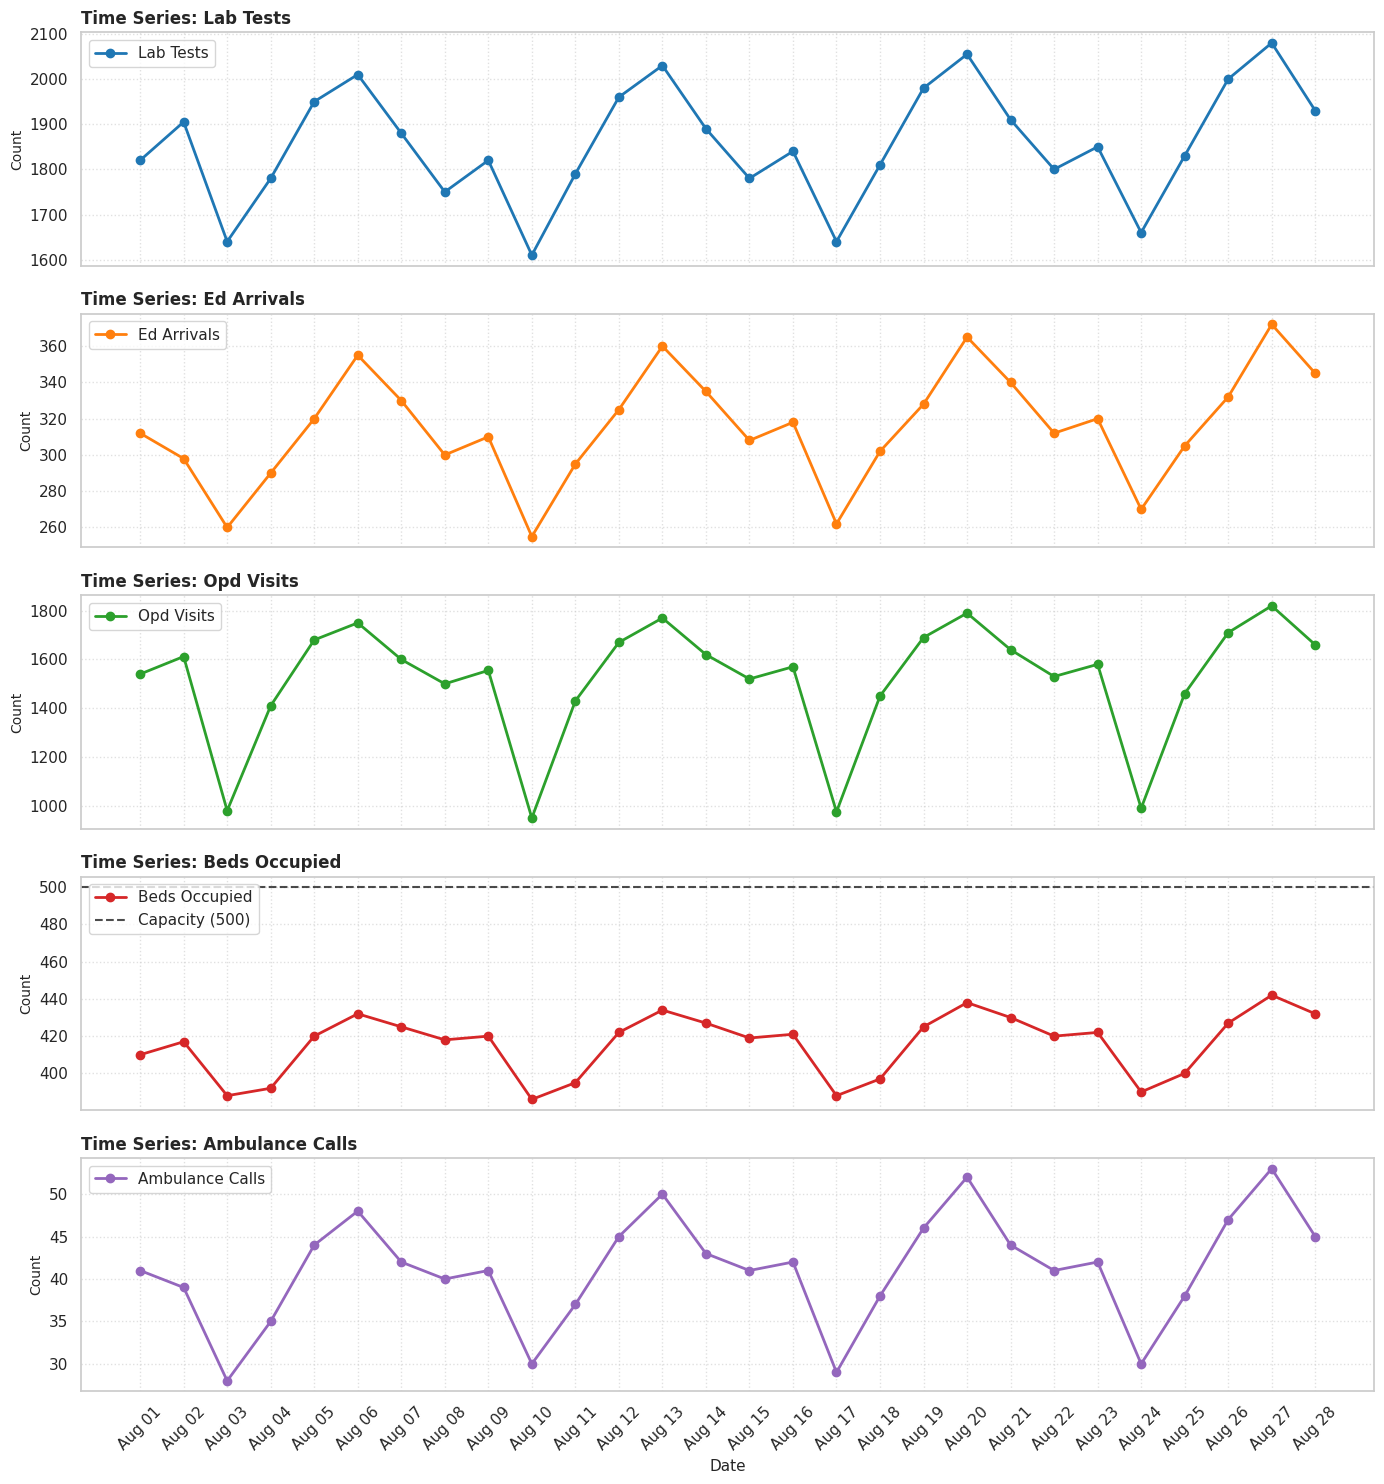

In [9]:
import matplotlib.pyplot as plt

target_cols = [
    "lab_tests",
    "ed_arrivals",
    "opd_visits",
    "beds_occupied",
    "ambulance_calls",
]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]

fig, axes = plt.subplots(
    nrows=len(target_cols), ncols=1, figsize=(14, 15), sharex=True
)

for i, (col, color) in enumerate(zip(target_cols, colors)):
    axes[i].plot(
        df["date"],
        df[col],
        marker="o",
        linewidth=2,
        color=color,
        label=col.replace("_", " ").title(),
    )

    # Special handling for beds_occupied: show capacity threshold
    if col == "beds_occupied":
        axes[i].axhline(
            y=df["beds_total"].iloc[0],
            color="black",
            linestyle="--",
            alpha=0.7,
            label=f"Capacity ({df['beds_total'].iloc[0]})",
        )

    axes[i].set_title(
        f"Time Series: {col.replace('_', ' ').title()}",
        fontsize=12,
        fontweight="bold",
        loc="left",
    )
    axes[i].set_ylabel("Count", fontsize=10)
    axes[i].grid(True, linestyle=":", alpha=0.6)
    axes[i].legend(loc="upper left")

# Format X-axis
axes[-1].set_xlabel("Date", fontsize=11)
plt.xticks(df["date"], df["date"].dt.strftime("%b %d"), rotation=45)
plt.tight_layout()
plt.show()

##Daywise Plots To Identify weekly trends in each features.

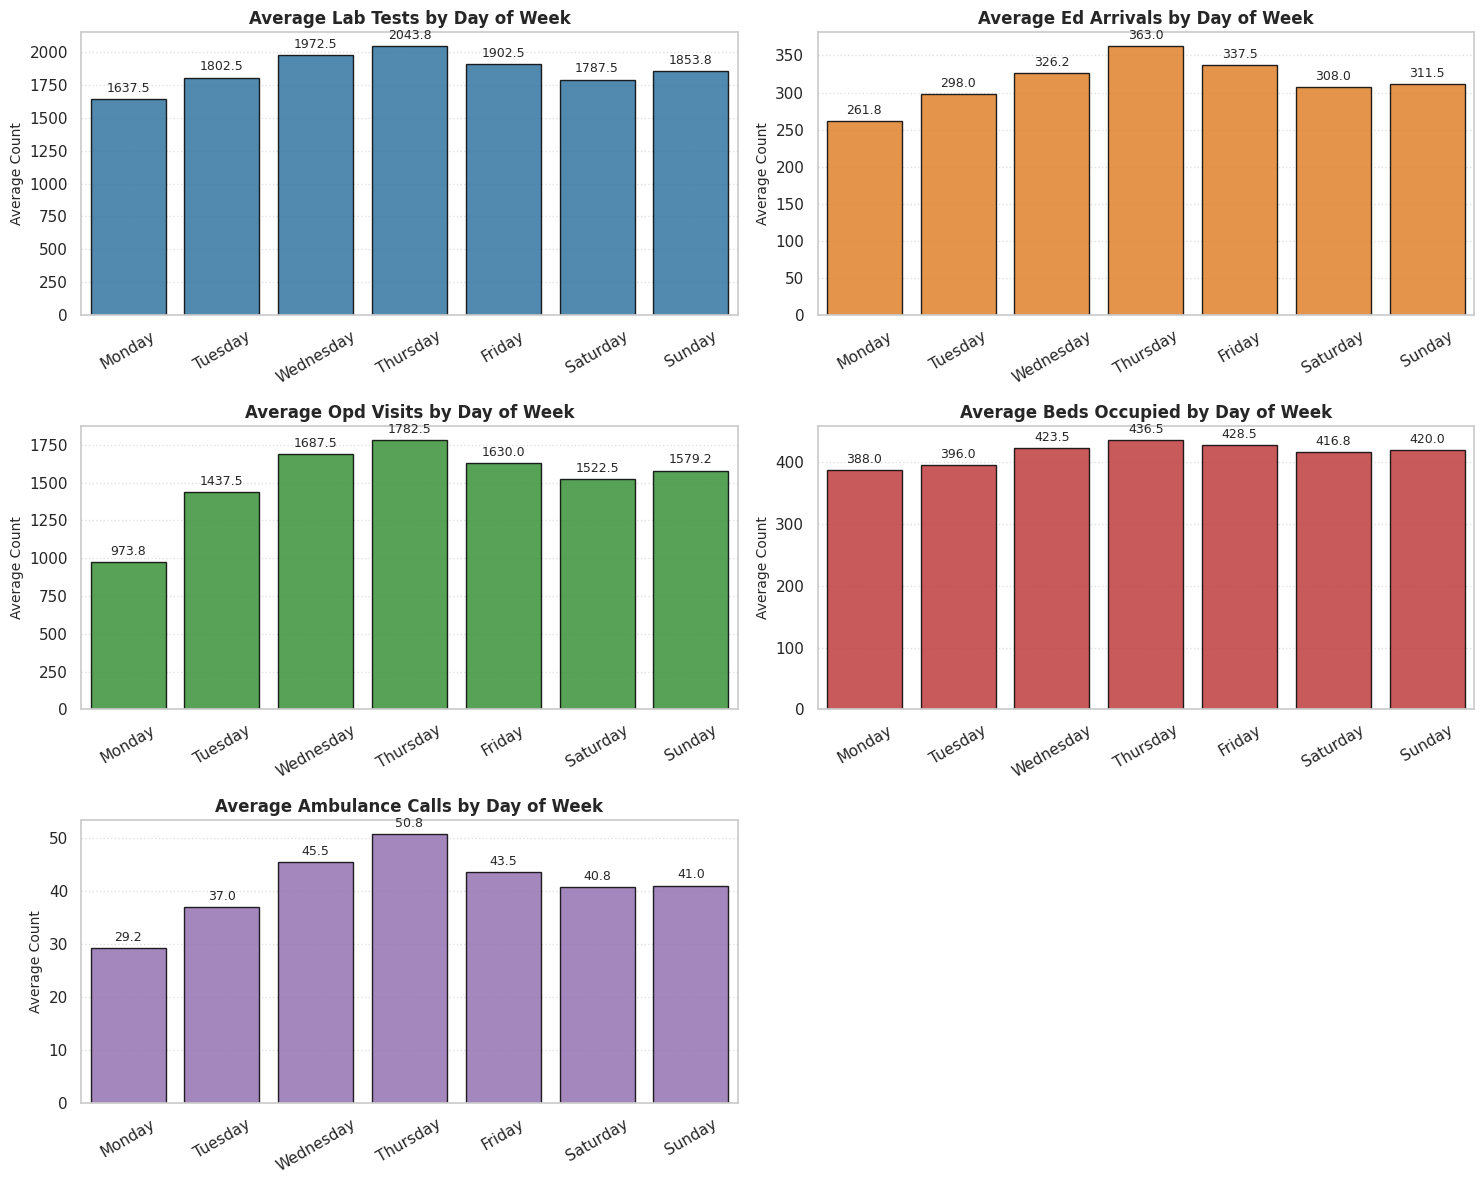

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

# Calculate mean metric values by day of week
dow_df = df.groupby("day_name")[target_cols].mean().reindex(day_order)

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 12))
axes = axes.flatten()

for i, (col, color) in enumerate(zip(target_cols, colors)):
    sns.barplot(
        x=dow_df.index,
        y=dow_df[col],
        ax=axes[i],
        color=color,
        edgecolor="black",
        alpha=0.85,
    )

    axes[i].set_title(
        f"Average {col.replace('_', ' ').title()} by Day of Week",
        fontsize=12,
        fontweight="bold",
    )
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Average Count", fontsize=10)
    axes[i].tick_params(axis="x", rotation=30)
    axes[i].grid(True, axis="y", linestyle=":", alpha=0.6)

    # Add data value labels on top of bars
    for p in axes[i].patches:
        axes[i].annotate(
            f"{p.get_height():.1f}",
            (p.get_x() + p.get_width() / 2.0, p.get_height()),
            ha="center",
            va="bottom",
            fontsize=9,
            xytext=(0, 3),
            textcoords="offset points",
        )

# Remove empty 6th subplot
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

###From the bar charts we can clearly see that thursday is likely more busy day as compared to other days of week.

##**Feature Engineering**

###Calander feature Extraction

In [11]:
# 1. Calendar Features (Extracted directly from 'date')
df["day_of_week"] = df["date"].dt.dayofweek  # Monday=0, Sunday=6
df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)  # 1 for Sat/Sun, 0 otherwise
df["month"] = df["date"].dt.month

print("Extracted Calendar Features:")
display(df[["date", "day_name", "day_of_week", "is_weekend", "month"]].head())

Extracted Calendar Features:


,date,day_name,day_of_week,is_weekend,month
0,2026-08-01,Saturday,5,1,8
1,2026-08-02,Sunday,6,1,8
2,2026-08-03,Monday,0,0,8
3,2026-08-04,Tuesday,1,0,8
4,2026-08-05,Wednesday,2,0,8


###Creating target metrics and lag features

In [12]:
# Create lag_1 and lag_7 for each of the 5 forecast targets
target_metrics = [
    "lab_tests",
    "ed_arrivals",
    "opd_visits",
    "beds_occupied",
    "ambulance_calls",
]

for metric in target_metrics:
  df[f"{metric}_lag_1"] = df[metric].shift(1)
  df[f"{metric}_lag_7"] = df[metric].shift(7)

# Inspect lag columns for beds_occupied
print("Target Lags Example (beds_occupied):")
display(
    df[["date", "beds_occupied", "beds_occupied_lag_1", "beds_occupied_lag_7"]]
    .iloc[5:12]
    .reset_index(drop=True)
)

Target Lags Example (beds_occupied):


,date,beds_occupied,beds_occupied_lag_1,beds_occupied_lag_7
0,2026-08-06,432,420.0,NaN
1,2026-08-07,425,432.0,NaN
2,2026-08-08,418,425.0,410.0
3,2026-08-09,420,418.0,417.0
4,2026-08-10,386,420.0,388.0
5,2026-08-11,395,386.0,392.0
6,2026-08-12,422,395.0,420.0


###Adding rolling mean for targeted features for better performance at model training and prediction

In [13]:
# Compute 7-day rolling mean strictly on past observed values (shift 1 first)
for metric in target_metrics:
  df[f"{metric}_rolling_mean_7"] = (
      df[metric].shift(1).rolling(window=7, min_periods=1).mean()
  )

# Verify no leakage (the rolling mean on day t only includes days t-1 through t-7)
print("Leakage-Free 7-Day Rolling Mean (beds_occupied):")
display(
    df[
        [
            "date",
            "beds_occupied",
            "beds_occupied_lag_1",
            "beds_occupied_rolling_mean_7",
        ]
    ]
    .iloc[6:13]
    .reset_index(drop=True)
)

Leakage-Free 7-Day Rolling Mean (beds_occupied):


,date,beds_occupied,beds_occupied_lag_1,beds_occupied_rolling_mean_7
0,2026-08-07,425,432.0,409.833333
1,2026-08-08,418,425.0,412.000000
2,2026-08-09,420,418.0,413.142857
3,2026-08-10,386,420.0,413.571429
4,2026-08-11,395,386.0,413.285714
5,2026-08-12,422,395.0,413.714286
6,2026-08-13,434,422.0,414.000000


In [14]:
df.head()

,date,facility_id,facility_type,lab_tests,ed_arrivals,opd_visits,admissions,discharges,beds_occupied,beds_total,...,opd_visits_lag_7,beds_occupied_lag_1,beds_occupied_lag_7,ambulance_calls_lag_1,ambulance_calls_lag_7,lab_tests_rolling_mean_7,ed_arrivals_rolling_mean_7,opd_visits_rolling_mean_7,beds_occupied_rolling_mean_7,ambulance_calls_rolling_mean_7
0,2026-08-01,GMC-AHM-001,District Hospital,1820,312,1540,78,65,410,500,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-08-02,GMC-AHM-001,District Hospital,1905,298,1612,82,71,417,500,...,NaN,410.0,NaN,41.0,NaN,1820.000000,312.0,1540.000000,410.00,41.00
2,2026-08-03,GMC-AHM-001,District Hospital,1640,260,980,55,52,388,500,...,NaN,417.0,NaN,39.0,NaN,1862.500000,305.0,1576.000000,413.50,40.00
3,2026-08-04,GMC-AHM-001,District Hospital,1780,290,1410,70,68,392,500,...,NaN,388.0,NaN,28.0,NaN,1788.333333,290.0,1377.333333,405.00,36.00
4,2026-08-05,GMC-AHM-001,District Hospital,1950,320,1680,85,75,420,500,...,NaN,392.0,NaN,35.0,NaN,1786.250000,290.0,1385.500000,401.75,35.75


In [15]:
def get_features_for_metric(df_raw: pd.DataFrame, metric: str):
  """Builds a leakage-free feature set for a single forecast target metric.

  Total features: 6 (day_of_week, is_weekend, month, lag_1, lag_7,
  rolling_mean_7)
  """
  data = df_raw.copy()

  # Calendar features
  data["day_of_week"] = data["date"].dt.dayofweek
  data["is_weekend"] = data["day_of_week"].isin([5, 6]).astype(int)
  data["month"] = data["date"].dt.month

  # Lag and Rolling features for the selected metric
  data["lag_1"] = data[metric].shift(1)
  data["lag_7"] = data[metric].shift(7)
  data["rolling_mean_7"] = (
      data[metric].shift(1).rolling(window=7, min_periods=1).mean()
  )

  feature_cols = [
      "day_of_week",
      "is_weekend",
      "month",
      "lag_1",
      "lag_7",
      "rolling_mean_7",
  ]

  # Drop rows with NaNs resulting from lag_7 shifts
  clean_df = data.dropna(subset=feature_cols).reset_index(drop=True)

  return clean_df, feature_cols


# Quick check of final feature set
sample_df, features = get_features_for_metric(df, "beds_occupied")
print(f"Total features per model: {len(features)} -> {features}")
print(f"Available training/evaluation rows: {len(sample_df)}")
display(sample_df[["date", "beds_occupied"] + features].head(3))

Total features per model: 6 -> ['day_of_week', 'is_weekend', 'month', 'lag_1', 'lag_7', 'rolling_mean_7']
Available training/evaluation rows: 21


,date,beds_occupied,day_of_week,is_weekend,month,lag_1,lag_7,rolling_mean_7
0,2026-08-08,418,5,1,8,425.0,410.0,412.000000
1,2026-08-09,420,6,1,8,418.0,417.0,413.142857
2,2026-08-10,386,0,0,8,420.0,388.0,413.571429


##**Modeling**

###Splits dataset

In [16]:
import numpy as np


def time_based_split(data_df: pd.DataFrame):
  """Splits the time series into Train (70%), Validation (15%), and Test (15%)

  chronologically without shuffling.
  """
  n = len(data_df)
  train_end = int(n * 0.70)
  val_end = int(n * 0.85)

  train = data_df.iloc[:train_end].copy()
  val = data_df.iloc[train_end:val_end].copy()
  test = data_df.iloc[val_end:].copy()

  return train, val, test


# Verify the split points on available clean rows
sample_df, _ = get_features_for_metric(df, "beds_occupied")
train_sample, val_sample, test_sample = time_based_split(sample_df)

print(
    f"Total rows after lag drops: {len(sample_df)} "
    f"(Dates: {sample_df['date'].min().strftime('%Y-%m-%d')} to {sample_df['date'].max().strftime('%Y-%m-%d')})"
)
print(
    f"Train set: {len(train_sample)} rows ({train_sample['date'].min().strftime('%Y-%m-%d')} to {train_sample['date'].max().strftime('%Y-%m-%d')})"
)
print(
    f"Val set:   {len(val_sample)} rows ({val_sample['date'].min().strftime('%Y-%m-%d')} to {val_sample['date'].max().strftime('%Y-%m-%d')})"
)
print(
    f"Test set:  {len(test_sample)} rows ({test_sample['date'].min().strftime('%Y-%m-%d')} to {test_sample['date'].max().strftime('%Y-%m-%d')})"
)

Total rows after lag drops: 21 (Dates: 2026-08-08 to 2026-08-28)
Train set: 14 rows (2026-08-08 to 2026-08-21)
Val set:   3 rows (2026-08-22 to 2026-08-24)
Test set:  4 rows (2026-08-25 to 2026-08-28)


In [21]:
def seasonal_naive_predict(df_split: pd.DataFrame) -> pd.Series:
  """Baseline: Predicts the value from the same day of the previous week (lag_7)."""
  return df_split["lag_7"]

In [22]:
import xgboost as xgb

# Dictionary to store trained models, test sets, and predictions for evaluation
models = {}
evaluation_records = []
test_predictions_dict = {}

# Single loop over all 5 target metrics as required by Part C
for metric in target_metrics:
  # 1. Generate leakage-free features
  df_feat, feature_cols = get_features_for_metric(df, metric)

  # 2. Apply time-based chronological split (70/15/15)
  train_data, val_data, test_data = time_based_split(df_feat)

  X_train, y_train = train_data[feature_cols], train_data[metric]
  X_val, y_val = val_data[feature_cols], val_data[metric]
  X_test, y_test = test_data[feature_cols], test_data[metric]

  # 3. Initialize and fit constrained XGBoost model (to prevent overfitting on small data)
  model = xgb.XGBRegressor(
      n_estimators=35,
      max_depth=2,
      learning_rate=0.05,
      subsample=0.85,
      colsample_bytree=0.85,
      reg_alpha=0.5,
      reg_lambda=1.5,
      random_state=42,
  )

  # Train on train set, validate on validation set
  model.fit(
      X_train,
      y_train,
      eval_set=[(X_val, y_val)],
      verbose=False,
  )

  # 4. Generate Predictions on the Test Set
  y_pred_baseline = seasonal_naive_predict(test_data)
  y_pred_xgb = model.predict(X_test)

  # 5. Store artifacts
  models[metric] = model
  test_predictions_dict[metric] = {
      "dates": test_data["date"].values,
      "actual": y_test.values,
      "baseline_pred": y_pred_baseline.values,
      "xgb_pred": y_pred_xgb,
  }

  print(f"✓ Model trained successfully for metric: '{metric}'")

✓ Model trained successfully for metric: 'lab_tests'
✓ Model trained successfully for metric: 'ed_arrivals'
✓ Model trained successfully for metric: 'opd_visits'
✓ Model trained successfully for metric: 'beds_occupied'
✓ Model trained successfully for metric: 'ambulance_calls'


##**Model Evaluation**

In [25]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error as mae
from sklearn.metrics import root_mean_squared_error as rmse

summary = []

for metric in target_metrics:
  y_true = test_predictions_dict[metric]["actual"]
  y_base = test_predictions_dict[metric]["baseline_pred"]
  y_xgb = test_predictions_dict[metric]["xgb_pred"]

  # Compute MAE & RMSE
  base_mae, base_rmse = mae(y_true, y_base), rmse(y_true, y_base)
  xgb_mae, xgb_rmse = mae(y_true, y_xgb), rmse(y_true, y_xgb)

  summary.append({
      "Metric": metric,
      "Baseline MAE": round(base_mae, 2),
      "XGBoost MAE": round(xgb_mae, 2),
      "Baseline RMSE": round(base_rmse, 2),
      "XGBoost RMSE": round(xgb_rmse, 2),
      "Best Model (MAE)": "XGBoost" if xgb_mae < base_mae else "Baseline",
  })

df_evaluation = pd.DataFrame(summary)
display(df_evaluation)

,Metric,Baseline MAE,XGBoost MAE,Baseline RMSE,XGBoost RMSE,Best Model (MAE)
0,lab_tests,21.25,57.35,21.36,69.21,Baseline
1,ed_arrivals,4.75,11.94,4.97,16.32,Baseline
2,opd_visits,20.00,70.78,21.21,88.84,Baseline
3,beds_occupied,2.75,5.37,2.87,7.77,Baseline
4,ambulance_calls,0.75,2.64,0.87,3.43,Baseline


In [27]:
# Display formatted table
display(df_evaluation.set_index("Metric"))

print("\n--- Evaluation Takeaways ---")
for _, row in df_evaluation.iterrows():
    print(f"• {row['Metric']}: Baseline MAE = {row['Baseline MAE']} vs XGBoost MAE = {row['XGBoost MAE']} -> Winner: {row['Best Model (MAE)']}")

,Baseline MAE,XGBoost MAE,Baseline RMSE,XGBoost RMSE,Best Model (MAE)
Metric,,,,,
lab_tests,21.25,57.35,21.36,69.21,Baseline
ed_arrivals,4.75,11.94,4.97,16.32,Baseline
opd_visits,20.00,70.78,21.21,88.84,Baseline
beds_occupied,2.75,5.37,2.87,7.77,Baseline
ambulance_calls,0.75,2.64,0.87,3.43,Baseline



--- Evaluation Takeaways ---
• lab_tests: Baseline MAE = 21.25 vs XGBoost MAE = 57.35 -> Winner: Baseline
• ed_arrivals: Baseline MAE = 4.75 vs XGBoost MAE = 11.94 -> Winner: Baseline
• opd_visits: Baseline MAE = 20.0 vs XGBoost MAE = 70.78 -> Winner: Baseline
• beds_occupied: Baseline MAE = 2.75 vs XGBoost MAE = 5.37 -> Winner: Baseline
• ambulance_calls: Baseline MAE = 0.75 vs XGBoost MAE = 2.64 -> Winner: Baseline


##**Generating final CSV File**

In [28]:
import pandas as pd
import numpy as np

facility_id = df["facility_id"].iloc[0]
model_name = "XGBoost"  # or "Seasonal Naive (Baseline)"

# Define forecast horizon: Next 7 days starting from 2026-08-29
last_date = df["date"].max()
forecast_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=7, freq="D")

all_forecast_records = []

# Generate 7-day multi-step recursive forecasts per metric
for metric in target_metrics:
    # Get historical values up to the last available day
    history_values = list(df[metric].values)
    model = models[metric]

    for f_date in forecast_dates:
        # Build features dynamically for the forecast date
        dow = f_date.dayofweek
        is_wknd = int(dow in [5, 6])
        mth = f_date.month
        lag_1 = history_values[-1]
        lag_7 = history_values[-7]
        rolling_mean_7 = np.mean(history_values[-7:])  # trailing 7-day mean

        # Prepare single-row input DataFrame
        X_future = pd.DataFrame([{
            "day_of_week": dow,
            "is_weekend": is_wknd,
            "month": mth,
            "lag_1": lag_1,
            "lag_7": lag_7,
            "rolling_mean_7": rolling_mean_7
        }])

        # Predict next step
        pred_val = float(model.predict(X_future)[0])
        history_values.append(pred_val)  # Append prediction recursively for future lags

        all_forecast_records.append({
            "facility_id": facility_id,
            "metric": metric,
            "forecast_date": f_date.strftime("%Y-%m-%d"),
            "forecast_value": round(pred_val, 1),
            "model_name": model_name
        })

# 1. Create DataFrame matching §4.1 Schema
df_forecasts = pd.DataFrame(all_forecast_records)
df_forecasts.to_csv("forecasts_next7.csv", index=False)

print("=== forecasts_next7.csv Created Successfully ===")
display(df_forecasts.head(14))

=== forecasts_next7.csv Created Successfully ===


,facility_id,metric,forecast_date,forecast_value,model_name
0,GMC-AHM-001,lab_tests,2026-08-29,1792.0,XGBoost
1,GMC-AHM-001,lab_tests,2026-08-30,1797.7,XGBoost
2,GMC-AHM-001,lab_tests,2026-08-31,1731.0,XGBoost
3,GMC-AHM-001,lab_tests,2026-09-01,1818.6,XGBoost
4,GMC-AHM-001,lab_tests,2026-09-02,1949.3,XGBoost
5,GMC-AHM-001,lab_tests,2026-09-03,1946.8,XGBoost
6,GMC-AHM-001,lab_tests,2026-09-04,1864.0,XGBoost
7,GMC-AHM-001,ed_arrivals,2026-08-29,307.5,XGBoost
8,GMC-AHM-001,ed_arrivals,2026-08-30,323.6,XGBoost
9,GMC-AHM-001,ed_arrivals,2026-08-31,283.0,XGBoost


In [29]:
# Bed capacity from dataset (static: 500)
bed_capacity = int(df["beds_total"].iloc[0])

# Filter forecasts for bed occupancy
bed_forecasts = df_forecasts[df_forecasts["metric"] == "beds_occupied"].copy()

# 2. Add capacity and breach flag matching §4.2 Schema
bed_forecasts["capacity"] = bed_capacity
bed_forecasts["breach"] = bed_forecasts["forecast_value"] > bed_capacity

# Select and order required columns
df_alerts = bed_forecasts[["facility_id", "metric", "forecast_date", "forecast_value", "capacity", "breach"]]
df_alerts.to_csv("capacity_alerts.csv", index=False)

print("=== capacity_alerts.csv Created Successfully ===")
display(df_alerts)

# Check if any breach occurred
breach_count = df_alerts["breach"].sum()
if breach_count > 0:
    print(f"\n⚠️ WARNING: {breach_count} capacity breach(es) detected in the next 7 days!")
else:
    print(f"\n✓ All forecasted bed occupancy levels are within capacity ({bed_capacity}).")

=== capacity_alerts.csv Created Successfully ===


,facility_id,metric,forecast_date,forecast_value,capacity,breach
21,GMC-AHM-001,beds_occupied,2026-08-29,419.3,500,False
22,GMC-AHM-001,beds_occupied,2026-08-30,421.4,500,False
23,GMC-AHM-001,beds_occupied,2026-08-31,398.7,500,False
24,GMC-AHM-001,beds_occupied,2026-09-01,399.9,500,False
25,GMC-AHM-001,beds_occupied,2026-09-02,427.4,500,False
26,GMC-AHM-001,beds_occupied,2026-09-03,427.4,500,False
27,GMC-AHM-001,beds_occupied,2026-09-04,427.1,500,False



✓ All forecasted bed occupancy levels are within capacity (500).
